In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import OrderedDict
from tqdm import tqdm

from datetime import date
import datetime

import warnings
warnings.filterwarnings("ignore")

In [16]:
# CUDA support 
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')
    
print(device)
#device = torch.device('cpu')

cuda:0


In [3]:
# the deep neural network
class MLP(torch.nn.Module):
    def __init__(self, layers, activation="relu", init="xavier"):
        super(MLP, self).__init__()
        
        # parameters
        self.depth = len(layers) - 1
        
        if activation == "relu":
            self.activation = torch.nn.ReLU()
        elif activation == "tanh":
            self.activation = torch.nn.Tanh()
        elif activation == "gelu":
            self.activation = torch.nn.GELU()
        else:
            raise ValueError("Unspecified activation type")
        
        
        layer_list = list()
        for i in range(self.depth - 1): 
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation))
            
        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)
        
        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

        if init=="xavier":
            self.xavier_init_weights()
        elif init=="kaiming":
            self.kaiming_init_weights()
    
    def xavier_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Xavier Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.xavier_uniform_(m.weight)
                    m.bias.data.fill_(0.0)

    def kaiming_init_weights(self):
        with torch.no_grad():
            print("Initializing Network with Kaiming Initialization..")
            for m in self.layers.modules():
                if hasattr(m, 'weight'):
                    nn.init.kaiming_uniform_(m.weight)
                    m.bias.data.fill_(0.0)
                        
    def forward(self, x):
        out = self.layers(x)
        return out
    
class DataGenerator(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        
    def __getitem__(self, index):
        return self.X[index], self.Y[index]
    
    def __len__(self):
        return len(self.X)

In [4]:
data_dir = "./1D-AEMpy/"

print(os.getcwd())

D:\projects\1D-AEMpy\mcl\2_preTraining-MLP


In [5]:
data_df = pd.read_csv("./../1_trainingData-MLP/COMBINED-erken_rappbode_fallingcreek.csv")
#data_df = data_df.drop(columns=['time'])
data_df

,depth,time,AirTemp_degC,Longwave_Wm-2,Latent_Wm-2,Sensible_Wm-2,Shortwave_Wm-2,lightExtinct_m-1,TKE_Jm-1,ShearStress_Nm-2,...,densityGradient,tempChange,ice,snow,snowice,Volume_m2,Osgood,MaxDepth_m,MeanDepth_m,obs_temp
0,0.25,2017-06-28 20:00:00,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,...,0.057128,16.833785,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400
1,0.75,2017-06-28 20:00:00,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,...,-0.000990,16.828023,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400
2,1.25,2017-06-28 20:00:00,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,...,-0.000160,16.827089,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400
3,1.75,2017-06-28 20:00:00,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,...,0.001422,16.835365,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.814190
4,2.25,2017-06-28 20:00:00,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,...,0.000891,16.840548,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.825920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563195,6.75,2023-07-04 14:00:00,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,...,-0.012350,6.054926,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.872310
11563196,7.25,2023-07-04 14:00:00,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,...,-0.006036,5.858013,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.876860
11563197,7.75,2023-07-04 14:00:00,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,...,-0.001722,5.798044,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.867625
11563198,8.25,2023-07-04 14:00:00,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,...,0.000726,5.823573,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.858390


In [6]:
datetime_list =[datetime.datetime.strptime(date, '%Y-%m-%d %H:%M:%S') for date in data_df['time']]
day_of_year_list = [t.timetuple().tm_yday for t in datetime_list]
time_of_day_list = [t.hour for t in datetime_list]

data_df['day_of_year']=day_of_year_list
data_df['time_of_day']=time_of_day_list

In [7]:
data_df = data_df.drop(columns=['time'])
data_df

,depth,AirTemp_degC,Longwave_Wm-2,Latent_Wm-2,Sensible_Wm-2,Shortwave_Wm-2,lightExtinct_m-1,TKE_Jm-1,ShearStress_Nm-2,Area_m2,...,ice,snow,snowice,Volume_m2,Osgood,MaxDepth_m,MeanDepth_m,obs_temp,day_of_year,time_of_day
0,0.25,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400,179,20
1,0.75,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400,179,20
2,1.25,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.810400,179,20
3,1.75,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.814190,179,20
4,2.25,14.284031,-101.205668,-80.463293,-9.855218,65.608673,0.63,1.296112e+06,0.006140,2.367000e+07,...,0.0,0.0,0.0,2.136263e+08,2.855057,21.75,10.025190,16.825920,179,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563195,6.75,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,1.198809e+05,...,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.872310,185,14
11563196,7.25,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,1.198809e+05,...,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.876860,185,14
11563197,7.75,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,1.198809e+05,...,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.867625,185,14
11563198,8.25,23.289200,-70.917406,-12.275920,1.072818,544.901536,1.30,4.862209e+00,0.000466,1.198809e+05,...,0.0,0.0,0.0,3.222784e+05,8.764344,9.75,3.688313,10.858390,185,14


In [8]:
for col in data_df.columns:
    print(col)

depth
AirTemp_degC
Longwave_Wm-2
Latent_Wm-2
Sensible_Wm-2
Shortwave_Wm-2
lightExtinct_m-1
TKE_Jm-1
ShearStress_Nm-2
Area_m2
CC
ea
Jlw
Uw
Pa
RH
PP
IceSnowAttCoeff
iceFlag
icemovAvg
density_snow
ice_prior
snow_prior
snowice_prior
rho_snow_prior
IceSnowAttCoeff_prior
iceFlag_prior
dt_iceon_avg_prior
icemovAvg_prior
temp_init00
temp_heat01
temp_ice02
temp_diff03
temp_conv04
temp_mix05
buoyancy
diffusivity
densityGradient
tempChange
ice
snow
snowice
Volume_m2
Osgood
MaxDepth_m
MeanDepth_m
obs_temp
day_of_year
time_of_day


In [9]:
training_frac = 0.60
depth_steps = 50
number_days = len(data_df)#//depth_steps
n_obs = int(number_days*training_frac)#*depth_steps
print(f"Number of days total: {number_days}")
print(f"Number of training points: {n_obs}")

Number of days total: 11563200
Number of training points: 6937920


# Normalizing Data

In [10]:
data = data_df.values

train_data = data[:n_obs]
test_data = data[n_obs:]

#performing normalization on all the columns
scaler = StandardScaler()
scaler.fit(train_data)
train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

# Training Heat Diffusion Model

In [11]:
input_columns = ['depth', 'AirTemp_degC', 'Longwave_Wm-2', 'Latent_Wm-2', 'Sensible_Wm-2', 'Shortwave_Wm-2',
                'lightExtinct_m-1','Area_m2', 'Volume_m2', 'MaxDepth_m', 'MeanDepth_m',
                 'day_of_year', 'time_of_day', 'ice', 'snow', 'snowice', 'temp_init00']
output_columns = ['temp_heat01']

input_column_ix = [data_df.columns.get_loc(column) for column in input_columns]
output_column_ix = [data_df.columns.get_loc(column) for column in output_columns]

X_train, X_test = train_data[:,input_column_ix], test_data[:,input_column_ix]
y_train, y_test = train_data[:,output_column_ix], test_data[:,output_column_ix]

In [12]:
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (6937920, 17), X_test: (4625280, 17)
y_train: (6937920, 1), y_test: (4625280, 1)


In [13]:
#keeping track of the mean and standard deviations
train_mean = scaler.mean_
train_std = scaler.scale_

input_mean, input_std = train_mean[input_column_ix], train_std[input_column_ix]
output_mean, output_std = train_mean[output_column_ix], train_std[output_column_ix]

In [14]:
# Create data set
batch_size = 1024
train_dataset = DataGenerator(X_train, y_train)
test_dataset = DataGenerator(X_test, y_test)
# train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
# test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False)

In [18]:
layers = [X_train.shape[-1], 32, 32, y_train.shape[-1]]

model = MLP(layers, activation="gelu").to(device)

Initializing Network with Xavier Initialization..


In [19]:
lr = 1e-3
decay_rate = 0.1
decay_steps = 500
    
optimizer = torch.optim.Adam(model.parameters(), lr=lr, 
                         betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=decay_steps, gamma=decay_rate)

criterion = torch.nn.MSELoss()

In [20]:
print(model)

MLP(
  (activation): GELU(approximate='none')
  (layers): Sequential(
    (layer_0): Linear(in_features=17, out_features=32, bias=True)
    (activation_0): GELU(approximate='none')
    (layer_1): Linear(in_features=32, out_features=32, bias=True)
    (activation_1): GELU(approximate='none')
    (layer_2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [21]:
n_epochs = 100#1000

train_loss = []
test_loss = []
for it in tqdm(range(n_epochs)):
    loss_epoch = 0
    model.train()
    for x, y in iter(train_loader):
        x, y = x.to(device).float(), y.to(device).float()
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        loss_epoch += loss.detach().item()
    lr_scheduler.step()
    
    if it % 10 == 0:
        train_loss.append(loss_epoch/len(train_loader))
        model.eval()
        test_loss_epoch = 0
        for x, y in iter(test_loader):
            x, y = x.to(device).float(), y.to(device).float()
            pred = model(x)
            loss = criterion(pred, y)
            test_loss_epoch += loss.detach().item()
        test_loss.append(test_loss_epoch/len(test_loader))
        print(f"Epoch : {it}, Train_loss: {train_loss[-1]}, Test_loss: {test_loss[-1]}")
    

  1%|          | 1/100 [02:02<3:22:10, 122.53s/it]

Epoch : 0, Train_loss: 0.003725870273890512, Test_loss: 0.62357102542169


 11%|█         | 11/100 [15:32<2:13:34, 90.05s/it]

Epoch : 10, Train_loss: 2.0955095238702458e-05, Test_loss: 0.1778365064793628


 21%|██        | 21/100 [29:01<1:57:53, 89.53s/it]

...

 81%|████████  | 81/100 [1:49:44<28:19, 89.45s/it]

Epoch : 80, Train_loss: 1.7475037093951258e-06, Test_loss: 6.239337493039091


 91%|█████████ | 91/100 [2:03:08<13:22, 89.22s/it]

Epoch : 90, Train_loss: 1.1945499058689517e-06, Test_loss: 1.923554803904258


100%|██████████| 100/100 [2:14:36<00:00, 80.76s/it]


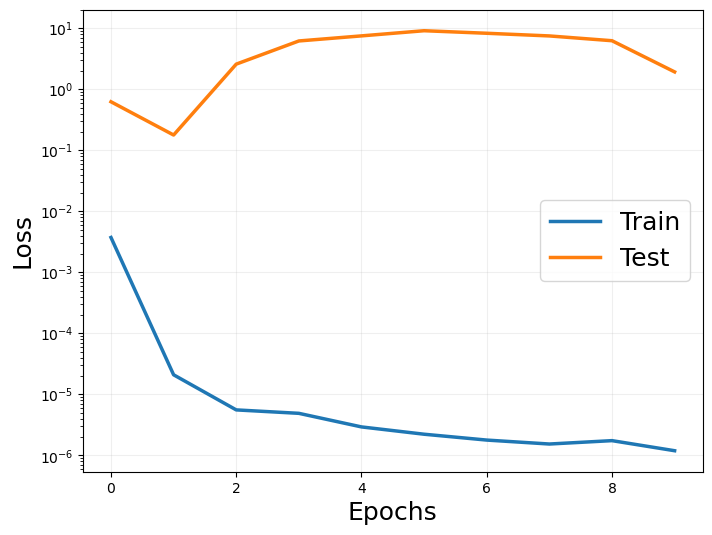

In [22]:
plt.figure(figsize=(8,6))
plt.plot(train_loss, label="Train", linewidth=2.5)
plt.plot(test_loss, label="Test", linewidth=2.5)
plt.grid("on", alpha=0.2)
plt.legend(fontsize=18)
plt.yscale("log")
plt.xlabel("Epochs", fontsize=18)
plt.ylabel("Loss", fontsize=18)
plt.show()

# Evaluating Results

In [23]:
def rmse(true, pred):
    return (((true-pred)**2).mean()**0.5).detach().cpu().numpy()

def l2_error(true, pred):
    return np.linalg.norm(pred.detach().cpu().numpy() - true.detach().cpu().numpy()) / np.linalg.norm(true.detach().cpu().numpy()) 

def compute_metrics(model, loader, mean=0.0, std=1.0):
    model.eval()
    y_ = []
    pred_ = []
    mean = torch.tensor(mean).to(device)
    std = torch.tensor(std).to(device)
    for x, y in iter(loader):
        x, y = x.to(device).float(), y.to(device).float()
        pred = model(x)
        y = y * std + mean
        pred = pred * std + mean
        y_.append(y)
        pred_.append(pred)
    y_ = torch.cat(y_, dim=0) 
    pred_ = torch.cat(pred_, dim=0)
    
    rmse_temp = rmse(y_[:,0], pred_[:,0])
    
    l2_error_temp = l2_error(y_[:,0], pred_[:,0])
    return rmse_temp, l2_error_temp

In [24]:
rmse_temp, l2_error_temp = compute_metrics(model, test_loader,  mean = output_mean, std = output_std)
print(f"Test Rmse of Temp: {rmse_temp}")
print(f"L2 Error  of Temp: {l2_error_temp}")

Test Rmse of Temp: 1.5419771953310806
L2 Error  of Temp: 0.18881817842193666


In [25]:
rmse_temp, l2_error_temp = compute_metrics(model, train_loader,  mean = output_mean, std = output_std)
print(f"Train Rmse of Temp: {rmse_temp}")
print(f"L2 Error  of Temp: {l2_error_temp}")

Train Rmse of Temp: 0.003457954731443734
L2 Error  of Temp: 0.0004263609131382799


# Saving Model

In [27]:
PATH = f"./saved_models/heating_model_time.pth"
torch.save(model.state_dict(), PATH)

In [ ]:
output_mean